In [19]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


In [20]:


data = pd.read_csv("weather prediction.csv")

# Display dataset
print("Dataset Preview:\n")
print(data.head())


Dataset Preview:

  Region Soil_Type     Crop  Rainfall_mm  Temperature_Celsius  \
0   West     Sandy   Cotton   897.077239            27.676966   
1  South      Clay     Rice   992.673282            18.026142   
2  North      Loam   Barley   147.998025            29.794042   
3  North     Sandy  Soybean   986.866331            16.644190   
4  South      Silt    Wheat   730.379174            31.620687   

   Fertilizer_Used  Irrigation_Used Weather_Condition  Days_to_Harvest  \
0            False             True            Cloudy              122   
1             True             True             Rainy              140   
2            False            False             Sunny              106   
3            False             True             Rainy              146   
4             True             True            Cloudy              110   

   Yield_tons_per_hectare  
0                6.555816  
1                8.527341  
2                1.127443  
3                6.517573  
4     

In [21]:
data_encoded = pd.get_dummies(data)


In [22]:

target_column = data_encoded.columns[-1]


In [23]:

X = data_encoded.drop(target_column, axis=1)
y = data_encoded[target_column]


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [25]:

model = DecisionTreeClassifier(random_state=42)


In [26]:

model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:

y_pred = model.predict(X_test)


In [28]:

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)



Accuracy: 1.0


In [29]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))




Classification Report:

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       130
        True       1.00      1.00      1.00        70

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [30]:

plt.figure(figsize=(20,10))


<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

[Text(0.6, 0.8333333333333334, 'Weather_Condition_Cloudy <= 0.5\ngini = 0.456\nsamples = 800\nvalue = [519, 281]\nclass = y[0]'),
 Text(0.4, 0.5, 'Weather_Condition_Rainy <= 0.5\ngini = 0.496\nsamples = 518\nvalue = [237, 281]\nclass = y[1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 281\nvalue = [0, 281]\nclass = y[1]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 237\nvalue = [237, 0]\nclass = y[0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 282\nvalue = [282, 0]\nclass = y[0]'),
 Text(0.7, 0.6666666666666667, '  False')]

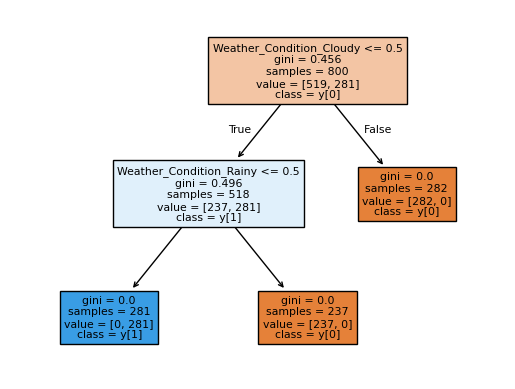

In [31]:

plot_tree(
    model,
    feature_names=X.columns,
    class_names=True,
    filled=True
)


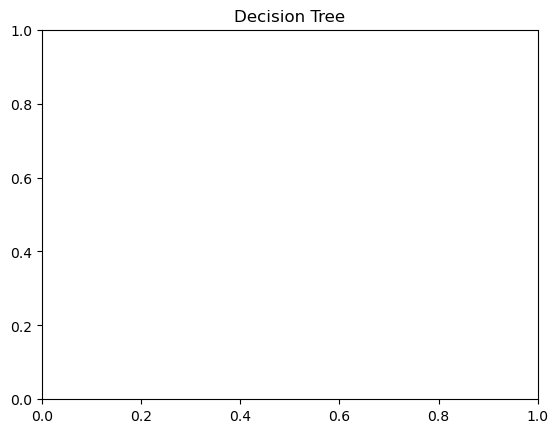

In [32]:

plt.title("Decision Tree")

plt.show()